# **German Credit Risk**

In [96]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
default_of_credit_card_clients = fetch_ucirepo(id=350) 
  
# data (as pandas dataframes) 
X = default_of_credit_card_clients.data.features 
y = default_of_credit_card_clients.data.targets 
  
# metadata 
print(default_of_credit_card_clients.metadata) 
  
# variable information 
print(default_of_credit_card_clients.variables) 


{'uci_id': 350, 'name': 'Default of Credit Card Clients', 'repository_url': 'https://archive.ics.uci.edu/dataset/350/default+of+credit+card+clients', 'data_url': 'https://archive.ics.uci.edu/static/public/350/data.csv', 'abstract': "This research aimed at the case of customers' default payments in Taiwan and compares the predictive accuracy of probability of default among six data mining methods.", 'area': 'Business', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 30000, 'num_features': 23, 'feature_types': ['Integer', 'Real'], 'demographics': ['Sex', 'Education Level', 'Marital Status', 'Age'], 'target_col': ['Y'], 'index_col': ['ID'], 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2009, 'last_updated': 'Fri Mar 29 2024', 'dataset_doi': '10.24432/C55S3H', 'creators': ['I-Cheng Yeh'], 'intro_paper': {'ID': 365, 'type': 'NATIVE', 'title': 'The comparisons of data mining techniques for the predictive accuracy of 

In [97]:
default_of_credit_card_clients.variables.description.to_list()

[nan,
 'LIMIT_BAL',
 'SEX',
 'EDUCATION',
 'MARRIAGE',
 'AGE',
 'PAY_0',
 'PAY_2',
 'PAY_3',
 'PAY_4',
 'PAY_5',
 'PAY_6',
 'BILL_AMT1',
 'BILL_AMT2',
 'BILL_AMT3',
 'BILL_AMT4',
 'BILL_AMT5',
 'BILL_AMT6',
 'PAY_AMT1',
 'PAY_AMT2',
 'PAY_AMT3',
 'PAY_AMT4',
 'PAY_AMT5',
 'PAY_AMT6',
 'default payment next month']

In [98]:
columns_names = [ 'LIMIT_BAL',
 'SEX',
 'EDUCATION',
 'MARRIAGE',
 'AGE',
 'PAY_0',
 'PAY_2',
 'PAY_3',
 'PAY_4',
 'PAY_5',
 'PAY_6',
 'BILL_AMT1',
 'BILL_AMT2',
 'BILL_AMT3',
 'BILL_AMT4',
 'BILL_AMT5',
 'BILL_AMT6',
 'PAY_AMT1',
 'PAY_AMT2',
 'PAY_AMT3',
 'PAY_AMT4',
 'PAY_AMT5',
 'PAY_AMT6',]

In [99]:
X.columns

Index(['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'X9', 'X10', 'X11',
       'X12', 'X13', 'X14', 'X15', 'X16', 'X17', 'X18', 'X19', 'X20', 'X21',
       'X22', 'X23'],
      dtype='str')

In [100]:
X.columns = columns_names

## *Feature Engineer**

In [101]:
X

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6
0,20000,2,2,1,24,2,2,-1,-1,-2,...,689,0,0,0,0,689,0,0,0,0
1,120000,2,2,2,26,-1,2,0,0,0,...,2682,3272,3455,3261,0,1000,1000,1000,0,2000
2,90000,2,2,2,34,0,0,0,0,0,...,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000
3,50000,2,2,1,37,0,0,0,0,0,...,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000
4,50000,1,2,1,57,-1,0,-1,0,0,...,35835,20940,19146,19131,2000,36681,10000,9000,689,679
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,220000,1,3,1,39,0,0,0,0,0,...,208365,88004,31237,15980,8500,20000,5003,3047,5000,1000
29996,150000,1,3,2,43,-1,-1,-1,-1,0,...,3502,8979,5190,0,1837,3526,8998,129,0,0
29997,30000,1,2,2,37,4,3,2,-1,0,...,2758,20878,20582,19357,0,0,22000,4200,2000,3100
29998,80000,1,3,1,41,1,-1,0,0,0,...,76304,52774,11855,48944,85900,3409,1178,1926,52964,1804


array([[<Axes: title={'center': 'Y'}>]], dtype=object)

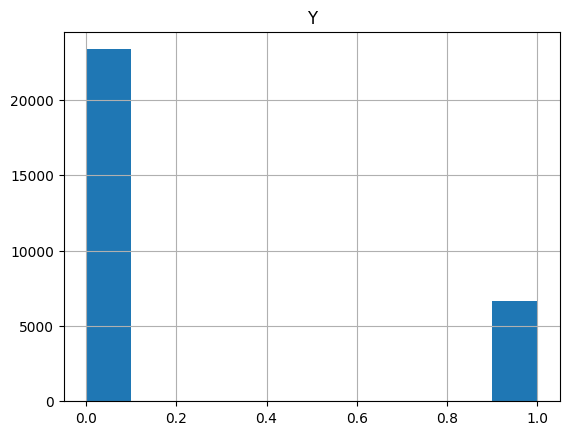

In [102]:
y.hist()

In [103]:
X

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6
0,20000,2,2,1,24,2,2,-1,-1,-2,...,689,0,0,0,0,689,0,0,0,0
1,120000,2,2,2,26,-1,2,0,0,0,...,2682,3272,3455,3261,0,1000,1000,1000,0,2000
2,90000,2,2,2,34,0,0,0,0,0,...,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000
3,50000,2,2,1,37,0,0,0,0,0,...,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000
4,50000,1,2,1,57,-1,0,-1,0,0,...,35835,20940,19146,19131,2000,36681,10000,9000,689,679
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,220000,1,3,1,39,0,0,0,0,0,...,208365,88004,31237,15980,8500,20000,5003,3047,5000,1000
29996,150000,1,3,2,43,-1,-1,-1,-1,0,...,3502,8979,5190,0,1837,3526,8998,129,0,0
29997,30000,1,2,2,37,4,3,2,-1,0,...,2758,20878,20582,19357,0,0,22000,4200,2000,3100
29998,80000,1,3,1,41,1,-1,0,0,0,...,76304,52774,11855,48944,85900,3409,1178,1926,52964,1804


## **EDA** 

Analisis de todas las variables, encontrar relaciones importantes, y crear variables

In [104]:
X.LIMIT_BAL.describe()

count      30000.000000
mean      167484.322667
std       129747.661567
min        10000.000000
25%        50000.000000
50%       140000.000000
75%       240000.000000
max      1000000.000000
Name: LIMIT_BAL, dtype: float64

<Axes: >

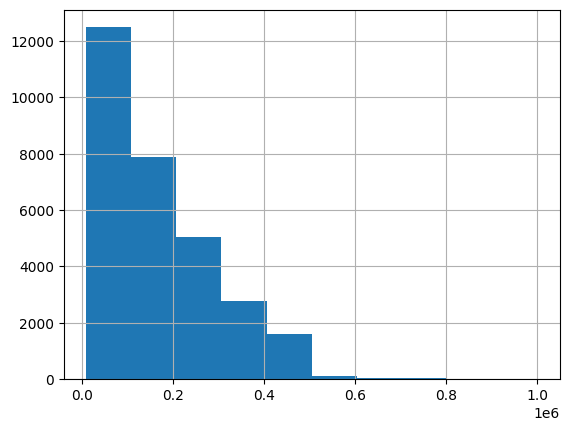

In [105]:
X.LIMIT_BAL.hist()

In [106]:
X["target"] = y

<Axes: >

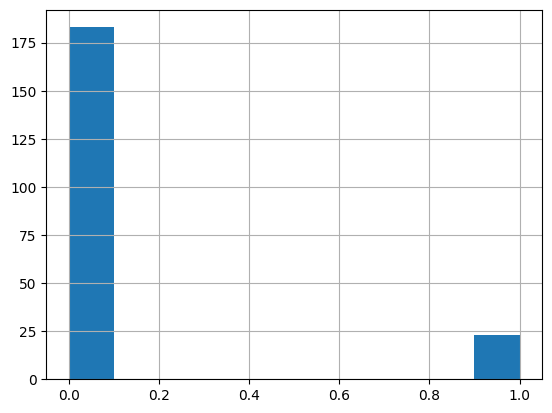

In [107]:
X[X["LIMIT_BAL"]>500000].target.hist()

### *Crear variables**

In [108]:
X.columns

Index(['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2',
       'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'target'],
      dtype='str')

In [109]:
import numpy as np

cols = ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']

X["flag"] = np.where(X[cols].ne(-1, 0).any(axis=1), 1, 0)

In [110]:
cols_bills = ['BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']

X["AVG_BILL"] = X[cols_bills].sum(axis=1)/6

In [111]:
X["RATIO_PAY_1"] = X["PAY_AMT1"]/X["BILL_AMT1"]
X["RATIO_PAY_2"] = X["PAY_AMT2"]/X["BILL_AMT2"]
X["RATIO_PAY_3"] = X["PAY_AMT3"]/X["BILL_AMT3"]

In [112]:
X.replace([np.inf, -np.inf], 0, inplace=True)

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,target,flag,AVG_BILL,RATIO_PAY_1,RATIO_PAY_2,RATIO_PAY_3
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,0,1,1,1284.000000,0.000000,0.222115,0.000000
1,120000,2,2,2,26,-1,2,0,0,0,...,1000,1000,0,2000,1,1,2846.166667,0.000000,0.579710,0.372856
2,90000,2,2,2,34,0,0,0,0,0,...,1000,1000,1000,5000,0,1,16942.166667,0.051917,0.106937,0.073752
3,50000,2,2,1,37,0,0,0,0,0,...,1200,1100,1069,1000,0,1,38555.666667,0.042562,0.041859,0.024345
4,50000,1,2,1,57,-1,0,-1,0,0,...,10000,9000,689,679,0,1,18223.166667,0.232099,6.469312,0.279057
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,220000,1,3,1,39,0,0,0,0,0,...,5003,3047,5000,1000,0,1,120891.500000,0.044986,0.103726,0.024011
29996,150000,1,3,2,43,-1,-1,-1,-1,0,...,8998,129,0,0,0,1,3530.333333,1.091503,1.928884,2.569389
29997,30000,1,2,2,37,4,3,2,-1,0,...,22000,4200,2000,3100,1,1,11749.333333,0.000000,0.000000,7.976795
29998,80000,1,3,1,41,1,-1,0,0,0,...,1178,1926,52964,1804,1,1,44435.166667,-52.218845,0.043494,0.015438


In [113]:
X["BILL_AMT1"]

0          3913
1          2682
2         29239
3         46990
4          8617
          ...  
29995    188948
29996      1683
29997      3565
29998     -1645
29999     47929
Name: BILL_AMT1, Length: 30000, dtype: int64

## **Feature Engineer**

In [114]:
len(X)

30000

In [115]:
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 29 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   LIMIT_BAL    30000 non-null  int64  
 1   SEX          30000 non-null  int64  
 2   EDUCATION    30000 non-null  int64  
 3   MARRIAGE     30000 non-null  int64  
 4   AGE          30000 non-null  int64  
 5   PAY_0        30000 non-null  int64  
 6   PAY_2        30000 non-null  int64  
 7   PAY_3        30000 non-null  int64  
 8   PAY_4        30000 non-null  int64  
 9   PAY_5        30000 non-null  int64  
 10  PAY_6        30000 non-null  int64  
 11  BILL_AMT1    30000 non-null  int64  
 12  BILL_AMT2    30000 non-null  int64  
 13  BILL_AMT3    30000 non-null  int64  
 14  BILL_AMT4    30000 non-null  int64  
 15  BILL_AMT5    30000 non-null  int64  
 16  BILL_AMT6    30000 non-null  int64  
 17  PAY_AMT1     30000 non-null  int64  
 18  PAY_AMT2     30000 non-null  int64  
 19  PAY_AMT3     30

In [116]:
X.isna().sum()

LIMIT_BAL         0
SEX               0
EDUCATION         0
MARRIAGE          0
AGE               0
PAY_0             0
PAY_2             0
PAY_3             0
PAY_4             0
PAY_5             0
PAY_6             0
BILL_AMT1         0
BILL_AMT2         0
BILL_AMT3         0
BILL_AMT4         0
BILL_AMT5         0
BILL_AMT6         0
PAY_AMT1          0
PAY_AMT2          0
PAY_AMT3          0
PAY_AMT4          0
PAY_AMT5          0
PAY_AMT6          0
target            0
flag              0
AVG_BILL          0
RATIO_PAY_1    1468
RATIO_PAY_2    1867
RATIO_PAY_3    2246
dtype: int64

## 1. Missing data fill

In [49]:
from sklearn.impute import SimpleImputer, KNNImputer, MissingIndicator

In [52]:
imputer_0 = SimpleImputer(strategy='constant', fill_value=0)

In [55]:
X

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,PAY_AMT4,PAY_AMT5,PAY_AMT6,target,flag,SUM_BILL,AVG_BILL,RATIO_PAY_1,RATIO_PAY_2,RATIO_PAY_3
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,1,1,7704,1284.000000,0.000000,0.222115,0.000000
1,120000,2,2,2,26,-1,2,0,0,0,...,1000,0,2000,1,1,17077,2846.166667,0.000000,0.579710,0.372856
2,90000,2,2,2,34,0,0,0,0,0,...,1000,1000,5000,0,1,101653,16942.166667,0.051917,0.106937,0.073752
3,50000,2,2,1,37,0,0,0,0,0,...,1100,1069,1000,0,1,231334,38555.666667,0.042562,0.041859,0.024345
4,50000,1,2,1,57,-1,0,-1,0,0,...,9000,689,679,0,1,109339,18223.166667,0.232099,6.469312,0.279057
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,220000,1,3,1,39,0,0,0,0,0,...,3047,5000,1000,0,1,725349,120891.500000,0.044986,0.103726,0.024011
29996,150000,1,3,2,43,-1,-1,-1,-1,0,...,129,0,0,0,1,21182,3530.333333,1.091503,1.928884,2.569389
29997,30000,1,2,2,37,4,3,2,-1,0,...,4200,2000,3100,1,1,70496,11749.333333,0.000000,0.000000,7.976795
29998,80000,1,3,1,41,1,-1,0,0,0,...,1926,52964,1804,1,1,266611,44435.166667,-52.218845,0.043494,0.015438


In [53]:
X_imputed = imputer_0.fit_transform(X)


## One-hot or codification strings

In [76]:
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
import pandas as pd

nominal_cols = ["EDUCATION"]

ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False, drop = "first")
X_sex = X[nominal_cols]
sex_encoded = ohe.fit_transform(X_sex)

In [77]:
sex_encoded

array([[0., 1., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0.],
       ...,
       [0., 1., 0., 0., 0., 0.],
       [0., 0., 1., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0.]], shape=(30000, 6))

In [78]:
ohe.get_feature_names_out(nominal_cols)

array(['EDUCATION_1', 'EDUCATION_2', 'EDUCATION_3', 'EDUCATION_4',
       'EDUCATION_5', 'EDUCATION_6'], dtype=object)

In [79]:
sex_df = pd.DataFrame(sex_encoded, columns=ohe.get_feature_names_out(nominal_cols))
sex_df

,EDUCATION_1,EDUCATION_2,EDUCATION_3,EDUCATION_4,EDUCATION_5,EDUCATION_6
0,0.0,1.0,0.0,0.0,0.0,0.0
1,0.0,1.0,0.0,0.0,0.0,0.0
2,0.0,1.0,0.0,0.0,0.0,0.0
3,0.0,1.0,0.0,0.0,0.0,0.0
4,0.0,1.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...
29995,0.0,0.0,1.0,0.0,0.0,0.0
29996,0.0,0.0,1.0,0.0,0.0,0.0
29997,0.0,1.0,0.0,0.0,0.0,0.0
29998,0.0,0.0,1.0,0.0,0.0,0.0


In [80]:
sex_df = pd.DataFrame(sex_encoded, columns=ohe.get_feature_names_out(nominal_cols))
pd.concat([X, sex_df], axis=1)

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,AVG_BILL,RATIO_PAY_1,RATIO_PAY_2,RATIO_PAY_3,EDUCATION_1,EDUCATION_2,EDUCATION_3,EDUCATION_4,EDUCATION_5,EDUCATION_6
0,20000,2,2,1,24,2,2,-1,-1,-2,...,1284.000000,0.000000,0.222115,0.000000,0.0,1.0,0.0,0.0,0.0,0.0
1,120000,2,2,2,26,-1,2,0,0,0,...,2846.166667,0.000000,0.579710,0.372856,0.0,1.0,0.0,0.0,0.0,0.0
2,90000,2,2,2,34,0,0,0,0,0,...,16942.166667,0.051917,0.106937,0.073752,0.0,1.0,0.0,0.0,0.0,0.0
3,50000,2,2,1,37,0,0,0,0,0,...,38555.666667,0.042562,0.041859,0.024345,0.0,1.0,0.0,0.0,0.0,0.0
4,50000,1,2,1,57,-1,0,-1,0,0,...,18223.166667,0.232099,6.469312,0.279057,0.0,1.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,220000,1,3,1,39,0,0,0,0,0,...,120891.500000,0.044986,0.103726,0.024011,0.0,0.0,1.0,0.0,0.0,0.0
29996,150000,1,3,2,43,-1,-1,-1,-1,0,...,3530.333333,1.091503,1.928884,2.569389,0.0,0.0,1.0,0.0,0.0,0.0
29997,30000,1,2,2,37,4,3,2,-1,0,...,11749.333333,0.000000,0.000000,7.976795,0.0,1.0,0.0,0.0,0.0,0.0
29998,80000,1,3,1,41,1,-1,0,0,0,...,44435.166667,-52.218845,0.043494,0.015438,0.0,0.0,1.0,0.0,0.0,0.0


In [ ]:
## Lo de arriba es explicativo, si tengo todo numerico no deberia hacer one-hot
X

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,PAY_AMT4,PAY_AMT5,PAY_AMT6,target,flag,SUM_BILL,AVG_BILL,RATIO_PAY_1,RATIO_PAY_2,RATIO_PAY_3
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,1,1,7704,1284.000000,0.000000,0.222115,0.000000
1,120000,2,2,2,26,-1,2,0,0,0,...,1000,0,2000,1,1,17077,2846.166667,0.000000,0.579710,0.372856
2,90000,2,2,2,34,0,0,0,0,0,...,1000,1000,5000,0,1,101653,16942.166667,0.051917,0.106937,0.073752
3,50000,2,2,1,37,0,0,0,0,0,...,1100,1069,1000,0,1,231334,38555.666667,0.042562,0.041859,0.024345
4,50000,1,2,1,57,-1,0,-1,0,0,...,9000,689,679,0,1,109339,18223.166667,0.232099,6.469312,0.279057
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,220000,1,3,1,39,0,0,0,0,0,...,3047,5000,1000,0,1,725349,120891.500000,0.044986,0.103726,0.024011
29996,150000,1,3,2,43,-1,-1,-1,-1,0,...,129,0,0,0,1,21182,3530.333333,1.091503,1.928884,2.569389
29997,30000,1,2,2,37,4,3,2,-1,0,...,4200,2000,3100,1,1,70496,11749.333333,0.000000,0.000000,7.976795
29998,80000,1,3,1,41,1,-1,0,0,0,...,1926,52964,1804,1,1,266611,44435.166667,-52.218845,0.043494,0.015438


## Escalamiento

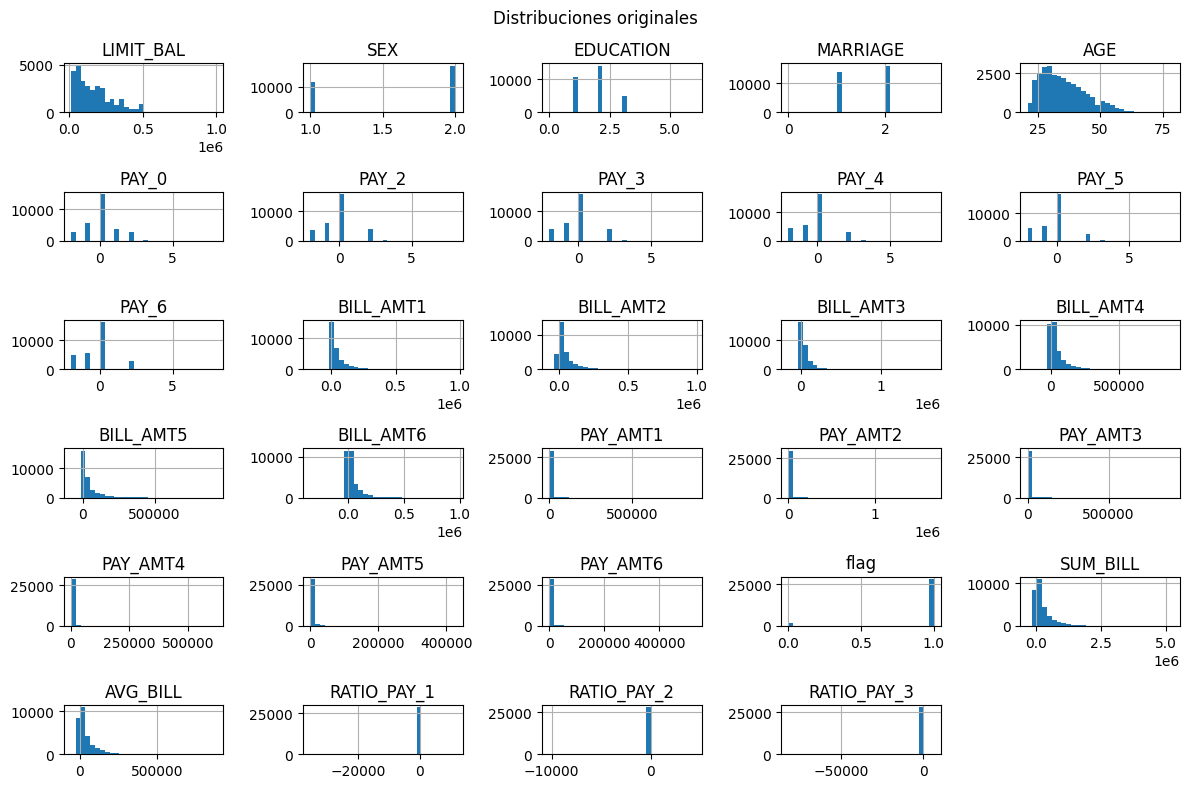

In [82]:
import matplotlib.pyplot as plt

X.drop(columns='target').hist(figsize=(12, 8), bins=30)
plt.suptitle('Distribuciones originales')
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit_transform()

array([[-1.13672015,  0.81016074,  0.18582826, ...,  0.00988139,
         0.01883207,  0.01071792],
       [-0.3659805 ,  0.81016074,  0.18582826, ...,  0.00988139,
         0.02214697,  0.01131364],
       [-0.59720239,  0.81016074,  0.18582826, ...,  0.01010046,
         0.01776437,  0.01083576],
       ...,
       [-1.05964618, -1.23432296,  0.18582826, ...,  0.00988139,
         0.01677307,  0.02346247],
       [-0.67427636, -1.23432296,  1.45111372, ..., -0.21046544,
         0.01717625,  0.01074259],
       [-0.90549825, -1.23432296,  0.18582826, ...,  0.01006433,
         0.01711426,  0.01076383]], shape=(30000, 30))

In [85]:
X

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,PAY_AMT4,PAY_AMT5,PAY_AMT6,target,flag,SUM_BILL,AVG_BILL,RATIO_PAY_1,RATIO_PAY_2,RATIO_PAY_3
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,1,1,7704,1284.000000,0.000000,0.222115,0.000000
1,120000,2,2,2,26,-1,2,0,0,0,...,1000,0,2000,1,1,17077,2846.166667,0.000000,0.579710,0.372856
2,90000,2,2,2,34,0,0,0,0,0,...,1000,1000,5000,0,1,101653,16942.166667,0.051917,0.106937,0.073752
3,50000,2,2,1,37,0,0,0,0,0,...,1100,1069,1000,0,1,231334,38555.666667,0.042562,0.041859,0.024345
4,50000,1,2,1,57,-1,0,-1,0,0,...,9000,689,679,0,1,109339,18223.166667,0.232099,6.469312,0.279057
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,220000,1,3,1,39,0,0,0,0,0,...,3047,5000,1000,0,1,725349,120891.500000,0.044986,0.103726,0.024011
29996,150000,1,3,2,43,-1,-1,-1,-1,0,...,129,0,0,0,1,21182,3530.333333,1.091503,1.928884,2.569389
29997,30000,1,2,2,37,4,3,2,-1,0,...,4200,2000,3100,1,1,70496,11749.333333,0.000000,0.000000,7.976795
29998,80000,1,3,1,41,1,-1,0,0,0,...,1926,52964,1804,1,1,266611,44435.166667,-52.218845,0.043494,0.015438


## Implementacion punta a punta

In [144]:
from sklearn.impute import SimpleImputer, KNNImputer, MissingIndicator
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report

numeric_simple = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),#, fill_value = 0)),
    ('scaler', StandardScaler())
])

categorical_simple = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(handle_unknown='ignore'))
])


In [145]:
X.columns

Index(['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2',
       'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'target',
       'flag', 'AVG_BILL', 'RATIO_PAY_1', 'RATIO_PAY_2', 'RATIO_PAY_3'],
      dtype='str')

In [146]:
num_cols = ['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2',
       'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6',
       'flag', 'AVG_BILL', 'RATIO_PAY_1', 'RATIO_PAY_2', 'RATIO_PAY_3']
cat_cols = ["EDUCATION"]

In [147]:

preprocess_simple = ColumnTransformer(transformers=[
    ('num', numeric_simple, num_cols),
    ('cat', categorical_simple, cat_cols)
])

In [148]:
model_simple = Pipeline(steps=[
    ('prep', preprocess_simple),
    ('clf', LogisticRegression(max_iter=2000))
])

In [149]:
X_dropped = X.drop(columns='target')
y = X['target']
X_train, X_test, y_train, y_test = train_test_split(X_dropped, y, test_size=0.25, stratify=y, random_state=12345)

In [150]:
X_train

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,flag,AVG_BILL,RATIO_PAY_1,RATIO_PAY_2,RATIO_PAY_3
26159,370000,2,3,2,31,-1,-1,-1,2,-1,...,42921,0,3728,2300,43183,1,14242.000000,0.597004,25.639785,0.000000
19218,220000,2,2,1,35,0,0,0,0,0,...,3000,1160,1000,0,1000,1,23913.166667,0.048474,0.080075,0.029372
7284,110000,2,2,2,24,1,2,2,0,0,...,0,10452,6475,51179,7760,1,48651.666667,0.057296,0.000000,0.153606
11304,500000,1,2,2,30,0,0,-2,-2,-2,...,3634,0,1907,0,210000,1,123957.833333,0.023729,0.009617,-0.000000
11172,60000,2,3,2,26,0,0,0,0,0,...,2000,1000,959,1300,500,1,40405.000000,0.035810,0.042063,0.020622
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18194,450000,1,3,2,38,0,0,0,0,0,...,11000,10013,20000,30000,30000,1,291240.500000,0.046526,0.036482,0.034513
28812,420000,2,2,2,37,0,0,0,0,0,...,1608,1700,2500,5065,1500,1,18848.833333,0.121433,0.098246,0.095996
3826,230000,1,3,1,38,-2,-2,-1,-1,0,...,188,6498,40000,12000,2500,1,19090.000000,0.000000,0.000000,34.563830
11283,30000,2,2,2,25,1,2,2,2,2,...,1200,0,2200,0,2500,1,27689.666667,0.060223,0.043706,0.000000


In [151]:
X_test

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,flag,AVG_BILL,RATIO_PAY_1,RATIO_PAY_2,RATIO_PAY_3
29158,50000,2,3,1,56,0,0,0,0,0,...,5000,1000,10160,16669,692,1,32134.500000,0.037983,0.113541,0.024681
12903,100000,1,3,2,27,0,0,0,0,0,...,2556,2802,1786,1850,2000,1,71400.000000,0.041987,0.025787,0.042360
19815,230000,2,2,1,40,0,0,0,0,0,...,2100,1500,1000,1000,1000,1,35156.666667,0.058985,0.059935,0.041013
16643,120000,1,1,2,35,-1,-1,-1,-1,-1,...,176,0,1428,0,476,1,351.000000,1.000000,0.539877,0.000000
29627,110000,1,2,2,35,0,0,0,0,0,...,3000,2000,2000,2000,2000,1,78503.000000,0.057217,0.027069,0.018192
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15494,20000,1,2,2,35,0,0,0,0,0,...,1363,1249,1000,2000,1000,1,19765.333333,0.066939,0.069209,0.062622
7730,50000,2,3,1,53,-1,-1,-1,-1,-1,...,5000,5000,4200,4810,4763,0,4469.833333,0.834376,1.299376,1.067920
27307,20000,1,2,1,37,0,0,0,0,0,...,2100,1000,132,47,0,1,7488.833333,0.095403,0.228733,0.137627
22486,480000,2,3,1,41,0,0,0,0,0,...,45000,12022,14000,14000,10000,1,78955.666667,0.799128,0.606862,0.111651


In [152]:
model_simple.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains spa

In [153]:
model_simple.predict(X_test)

array([0, 0, 0, ..., 0, 0, 1], shape=(7500,))

In [154]:
model_simple.predict_proba(X_test)

array([[0.76971814, 0.23028186],
       [0.81396227, 0.18603773],
       [0.78015499, 0.21984501],
       ...,
       [0.73534826, 0.26465174],
       [0.90725339, 0.09274661],
       [0.24600577, 0.75399423]], shape=(7500, 2))

In [155]:
model_simple.predict_proba(X_test)[:, 1]

array([0.23028186, 0.18603773, 0.21984501, ..., 0.26465174, 0.09274661,
       0.75399423], shape=(7500,))

In [156]:
pred_proba_simple = model_simple.predict_proba(X_test)[:, 1]
print('AUC simple imputer:', round(roc_auc_score(y_test, pred_proba_simple), 4))

AUC simple imputer: 0.7304
